In [ ]:
import numpy as np
import loompy
import scvelo as scv
import velocyto as vcy
import pandas as pd 
import scanpy as sc
import cellrank as cr
import matplotlib.pyplot as plt
import os



/home/shycheng/miniconda3/envs/py3.9/lib/python3.9/site-packages/loompy/normalize.py:2: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.22.1)
  import scipy.sparse as sparse


In [ ]:
adata = sc.read_h5ad("../../04.velocity/Neoblast.combined_loom/Neoblast.combined.h5ad")

In [ ]:
adata.obs["clusters"].cat.set_categories(['SSCs-1',
                                           'SSCs-2',
                                          #'SSCs-beta 2',
                                           'SSCs-3',
                                           'SSCs-4',
                                           'SSCs-5',
                                           'SSCs-6',
                                           'SSCs-7',
                                           #'SSCs-mu',
                                           'SSCs-8',
                                           'GSCs',
                                           'GSC progeny',
                                           'Female gametophyte',
                                           'Male gametophyte',
                                           'S1',
                                           'S1 progeny',
                                           'Early Vo',
                                           'Late Vo',
                                           #'Mature Vo',
                                           'Mehlis gland'], ordered=True, inplace=True)     

In [70]:
cb_palette = ["#7FC97F", "#BEAED4", "#FDC086", "#FFFF99" ,"#386CB0" ,"#1B9E77", "#D95F02", "#7570B3" ,"#E7298A",
             "#66A61E", "#E6AB02" ,"#A6761D" ,"#666666", "#A6CEE3","#1F78B4", "#B2DF8A" ,"#33A02C","#FB9A99"] #"#FB9A99"


computing velocity embedding
    finished (0:00:10) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/shycheng/miniconda3/envs/py3.10/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


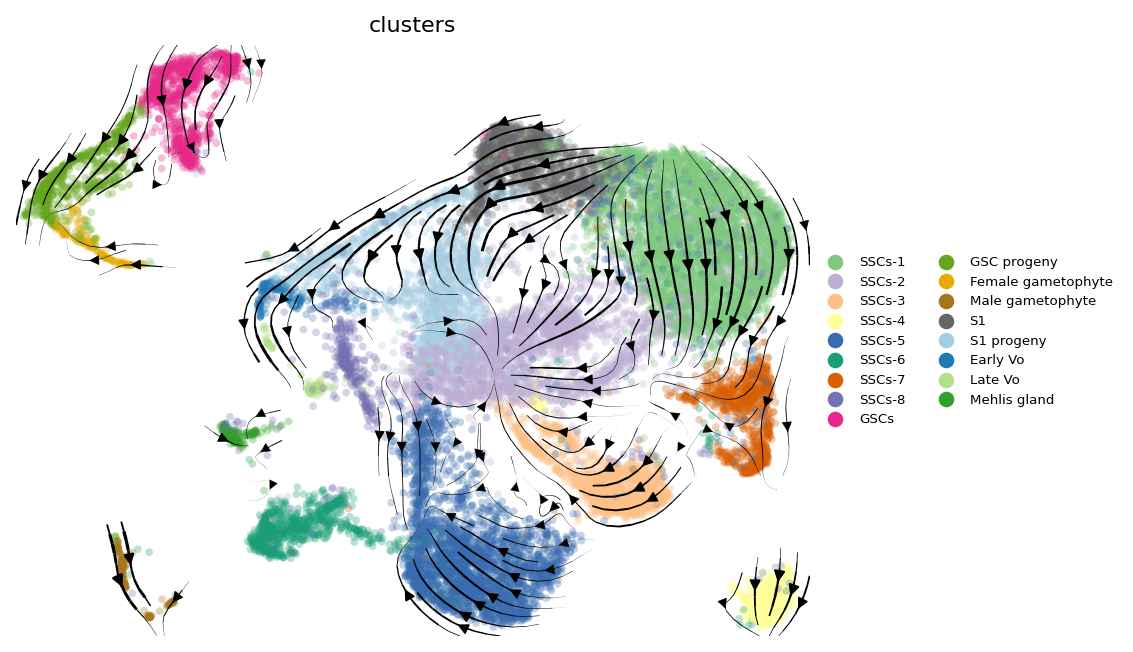

In [71]:
scv.pl.velocity_embedding_stream(adata, basis='umap',dpi=160,linewidth=0.8,legend_fontsize='6',colorbar=True,
                                 palette=cb_palette ,legend_loc='right margin') # ,save='../../02.figures/Analysis_20241126/Fig.pdf'

# Split by sex

## Female

/home/shycheng/miniconda3/envs/py3.10/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


saving figure to file ../../02.figures/NC_revised/Fig2B_a_revised.png


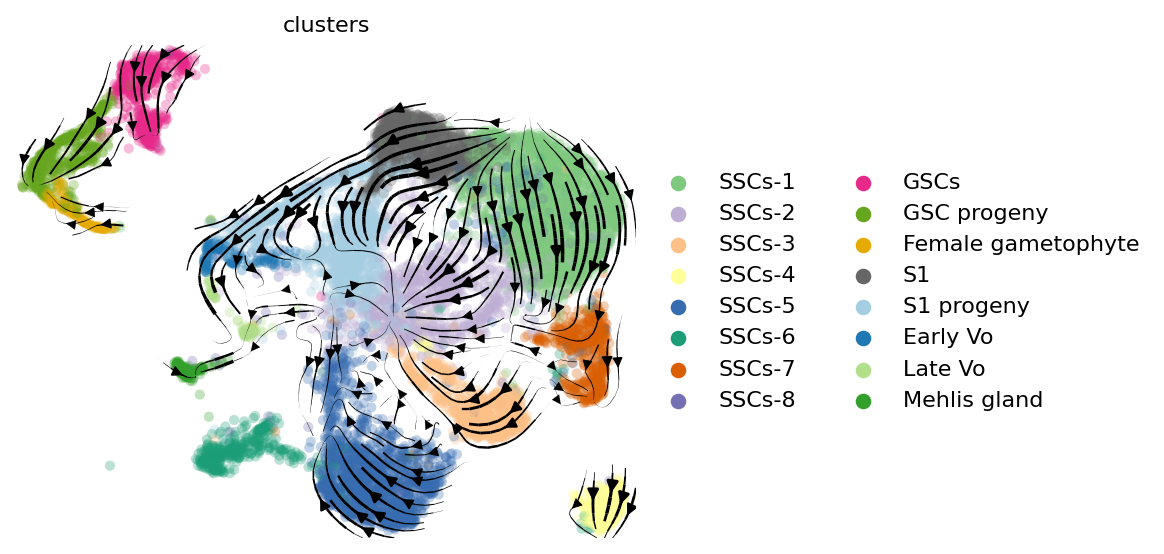

In [ ]:
adata_f = adata[[x for x in adata.obs.index.to_list() if "F" in x]]

cb_palette = ["#7FC97F", "#BEAED4", "#FDC086", "#FFFF99" ,"#386CB0" ,"#1B9E77", "#D95F02", "#7570B3" ,"#E7298A",
             "#66A61E", "#E6AB02" ,"#666666", "#A6CEE3","#1F78B4", "#B2DF8A" ,"#33A02C"] #"#FB9A99" "#A6761D" ,


scv.pl.velocity_embedding_stream(adata_f,
                                 palette=cb_palette,
                                 basis='umap',
                                 legend_loc='right margin',xlabel='umap1',
                                 ylabel='umap2',dpi=160,save="../../02.figures/NC_revised/Fig2B_a_revised.png",figsize=[5,4])

## Male

/home/shycheng/miniconda3/envs/py3.10/lib/python3.10/site-packages/scvelo/plotting/utils.py:942: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/home/shycheng/miniconda3/envs/py3.10/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


figure cannot be saved as pdf, using png instead (can only output finite numbers in pdf).
saving figure to file ../../02.figures/NC_revised/Fig2B_b_revised.png


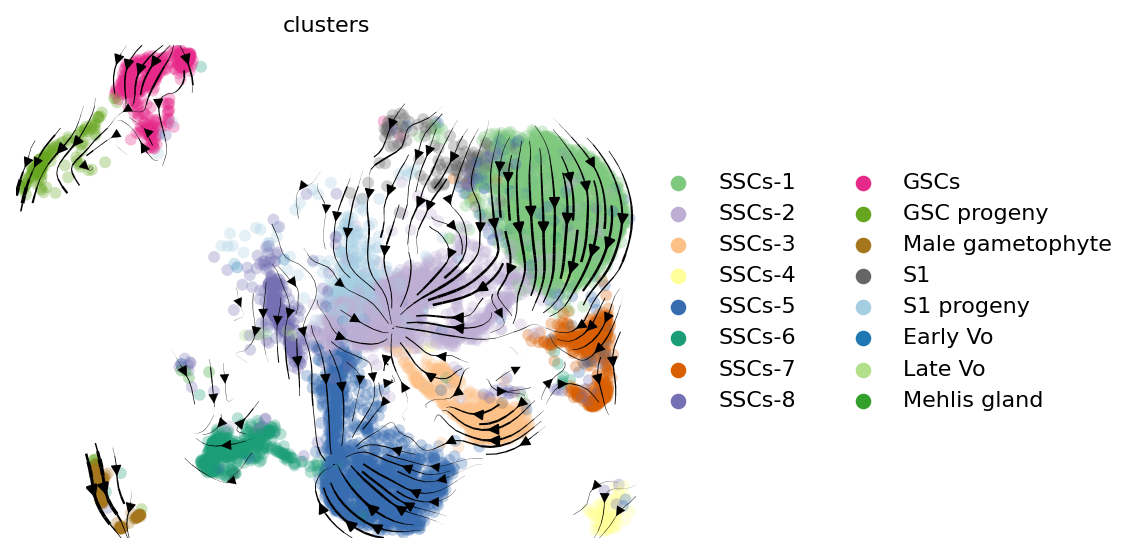

In [76]:
cb_palette = ["#7FC97F", "#BEAED4", "#FDC086", "#FFFF99" ,"#386CB0" ,"#1B9E77", "#D95F02", "#7570B3" ,"#E7298A",
             "#66A61E", "#A6761D" ,"#666666", "#A6CEE3","#1F78B4", "#B2DF8A" ,"#33A02C"] #"#FB9A99" "#E6AB02" ,
scv.pl.velocity_embedding_stream(adata[(adata.obs_names.str.contains("M")) & (adata.obs['clusters'] != 'Female gametophyte')],palette=cb_palette,
                                 basis='umap',legend_loc='right margin',xlabel='umap1',ylabel='umap2',dpi=160,
                                 save="../../02.figures/NC_revised/Fig2B_b_revised.pdf",figsize=[5,4])